In [1]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
# Load the trajectory and topology files
u = mda.Universe('/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD/EFE_solv.prmtop',
                 '/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD/Analysis/6-md_auto.nc')
#ref = mda.Universe('/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD_Replica/EFE_solv.prmtop','/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD_Replica/EFE_solv.pdb')
len(u.trajectory)

10000

In [4]:
# Calculate RMSD
rmsd = rms.RMSD(u, u, ref_frame=0, select='backbone')
rmsd.run()

# Convert frames to time
time_step = 0.1  # time step in nanoseconds
time = np.arange(len(rmsd.rmsd)) * time_step

# Calculate average RMSD
average_rmsd = np.mean(rmsd.rmsd[:, 2])

# Create a DataFrame with time and RMSD values
rmsd_df = pd.DataFrame({
    'Time (ns)': time,
    'RMSD (Å)': rmsd.rmsd[:, 2]
})

In [5]:

# Print the DataFrame and average RMSD
print("RMSD DataFrame:")
print(rmsd_df)
print(f"\nAverage RMSD: {average_rmsd:.2f} Å")

RMSD DataFrame:
      Time (ns)  RMSD (Å)
0           0.0  0.000001
1           0.1  0.889612
2           0.2  0.773723
3           0.3  0.821636
4           0.4  0.804290
...         ...       ...
9995      999.5  1.714858
9996      999.6  1.708459
9997      999.7  1.734873
9998      999.8  1.735373
9999      999.9  1.811467

[10000 rows x 2 columns]

Average RMSD: 1.52 Å


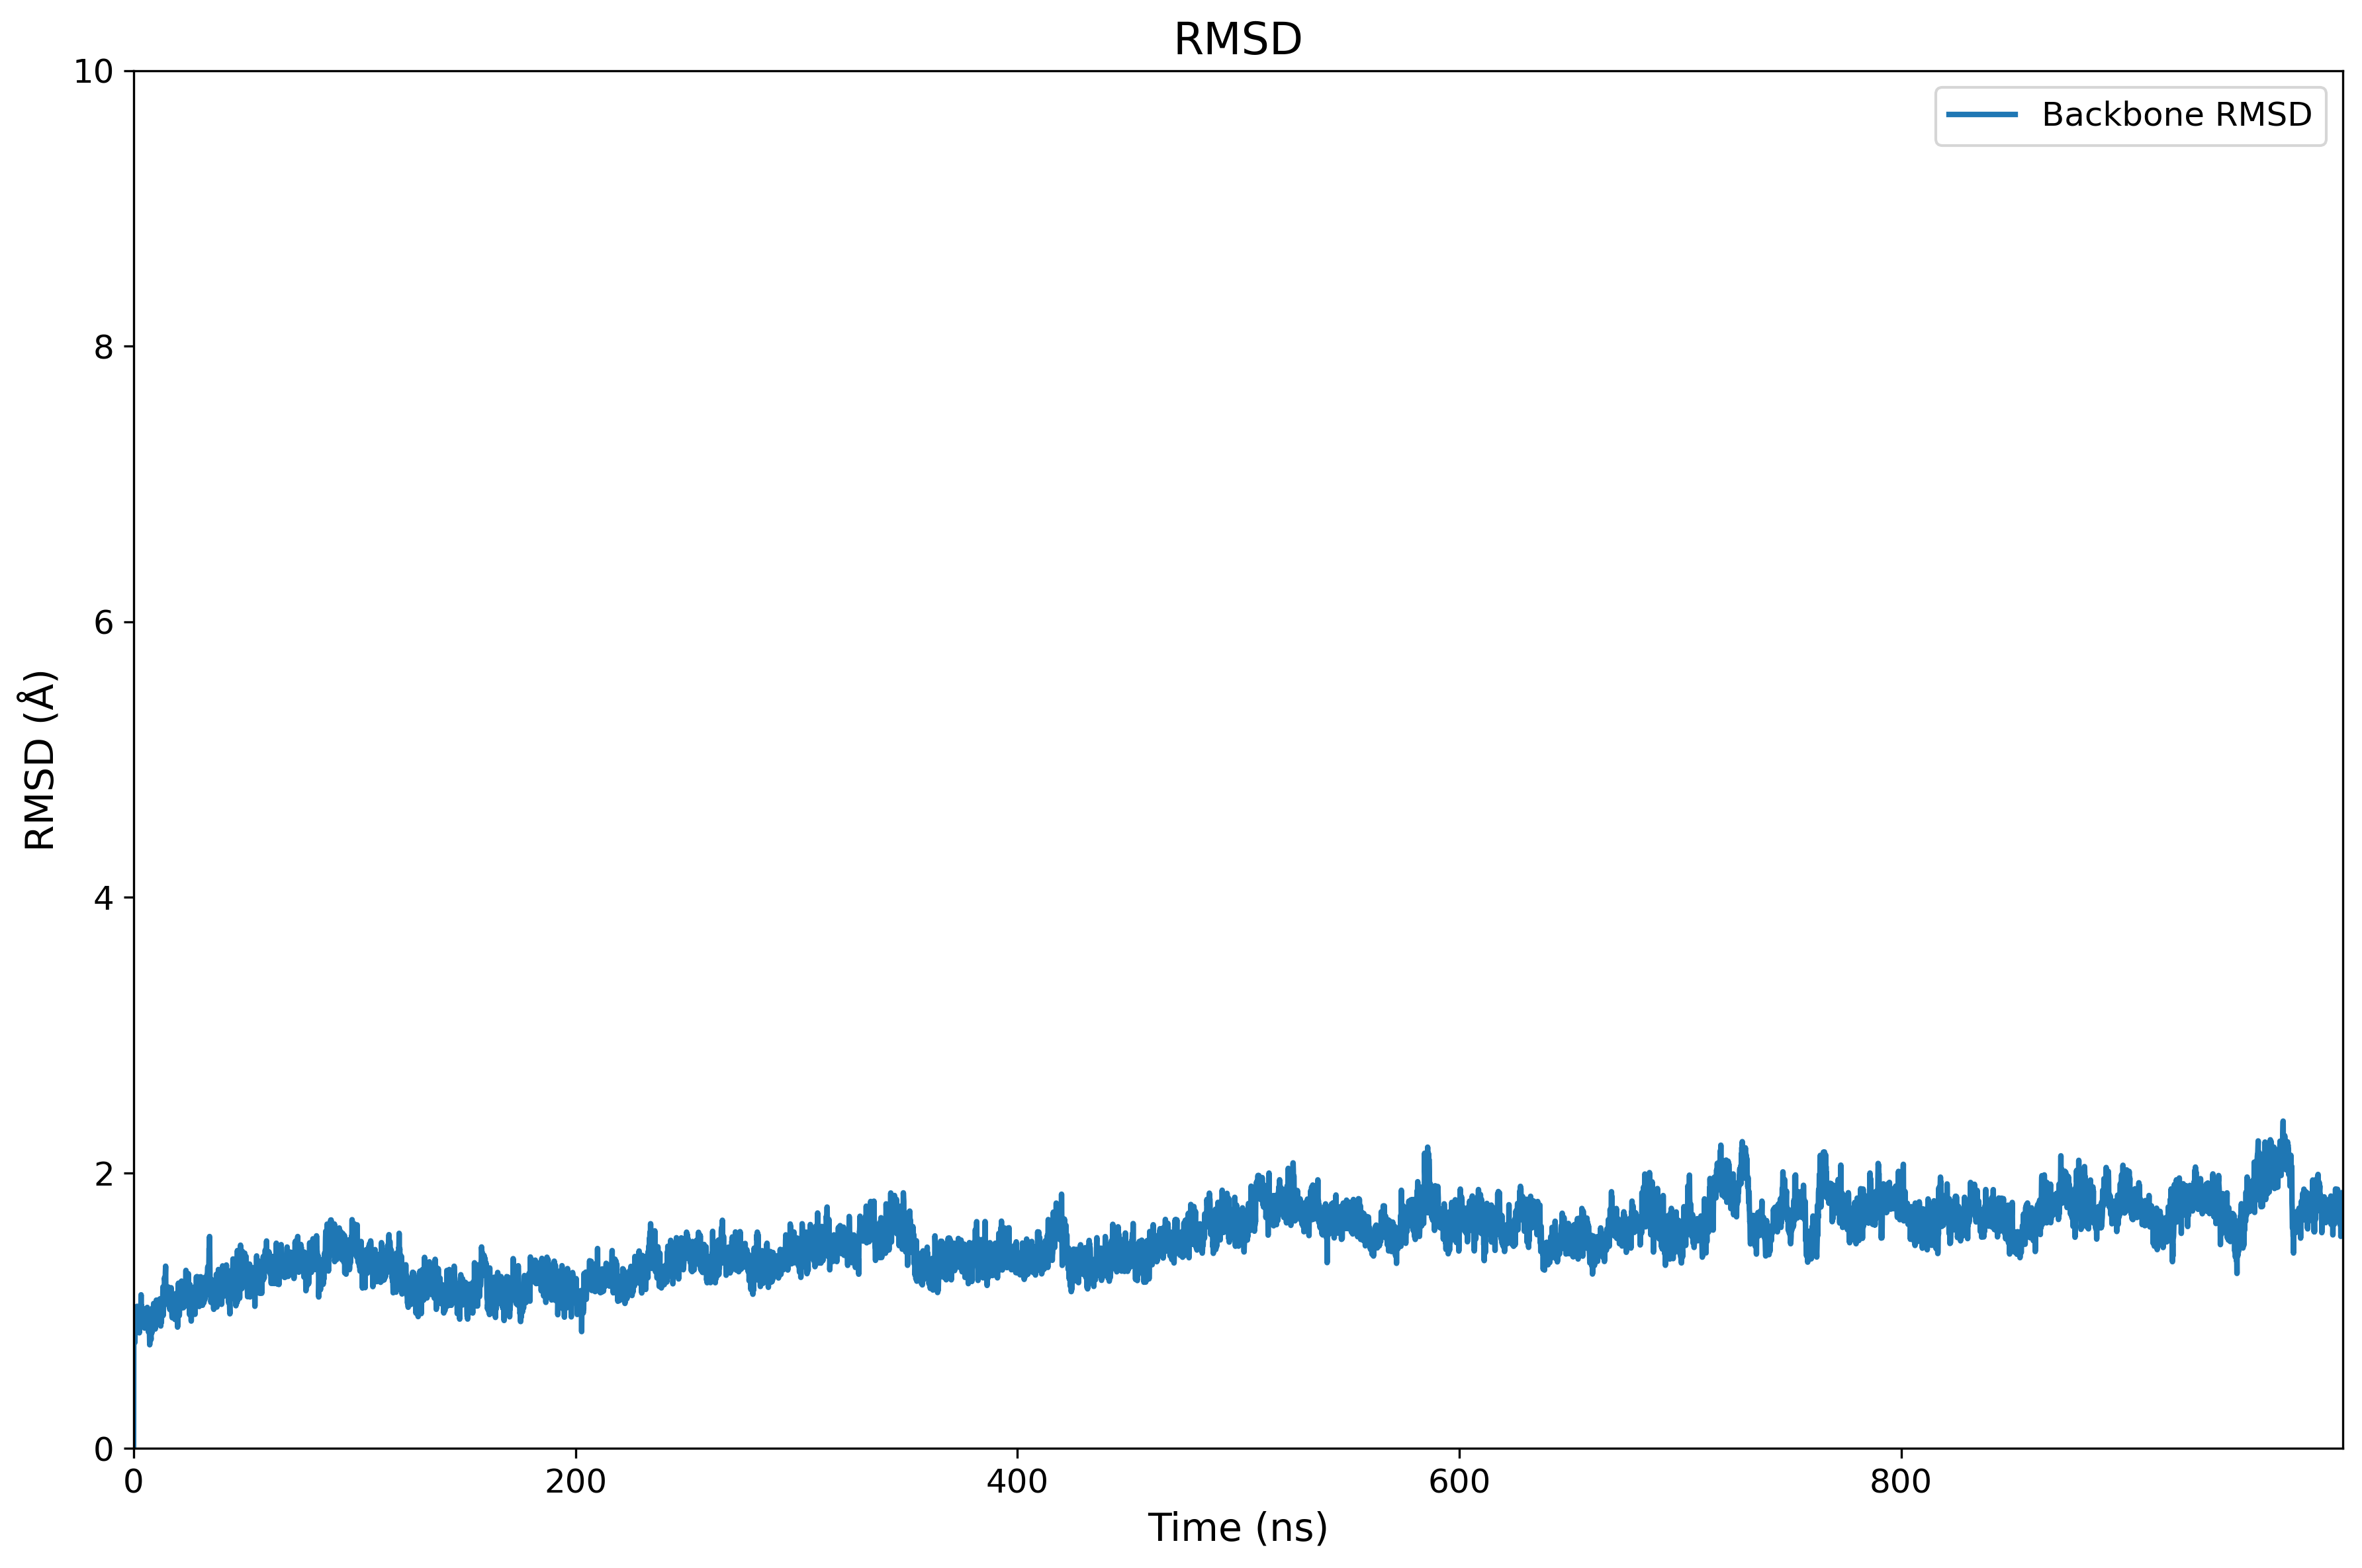

In [8]:
# Configure Matplotlib to use Arial font
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
# Plot RMSD with high quality settings
plt.figure(figsize=(12, 8), dpi=300)  # Set figure size and resolution
plt.plot(time, rmsd.rmsd[:, 2], label='Backbone RMSD', linewidth=2)
plt.xlabel('Time (ns)', fontsize=14)
plt.ylabel('RMSD (Å)', fontsize=14)
plt.title('RMSD', fontsize=16)
plt.legend(fontsize=12)
plt.xlim(0, time[-1])
plt.ylim(0, 10)
plt.grid(False)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# Calculate RMSF
rmsf = rms.RMSF(u.select_atoms('name CA')).run()
rmsf_values = rmsf.rmsf

In [5]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms, align, polymer
import matplotlib.pyplot as plt
import numpy as np

In [12]:
# Load the trajectory and topology files
u = mda.Universe('/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD/EFE_solv.prmtop',
                 '/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD/Analysis/6-md_auto.nc')
# Use the first frame as the reference
u.trajectory[0]
reference = u.select_atoms('protein')
# Select atoms for analysis (e.g., protein backbone)
protein = u.select_atoms('protein')
backbone = u.select_atoms('backbone')

In [17]:
from collections import Counter
# Select the substrate (replace with your actual selection criteria)
substrate = u.select_atoms('resname AG1')

# Define the frame step (e.g., every 100 ns in a 1 microsecond simulation with 10 ns frame spacing)
frame_step = int(100 / 10)  # Assuming each frame represents 10 ns
frames_to_analyze = list(range(0, len(u.trajectory), frame_step))

# Dictionary to count occurrences of residues within 5 Å of the substrate
residue_counter = Counter()

# Analyze each frame
for ts in u.trajectory[frames_to_analyze]:
    # Select amino acids within 5 Å of the substrate
    surrounding_residues = u.select_atoms(f'protein and around 5.0 substrate').residues
    for residue in surrounding_residues:
        residue_counter[residue.resname + str(residue.resid)] += 1

# Calculate the number of frames analyzed
total_frames = len(frames_to_analyze)

# Identify residues that are within 5 Å for at least 80% of the time
threshold = 0.8 * total_frames
significant_residues = [res for res, count in residue_counter.items() if count >= threshold]

# Report the results
print("Residues within 5 Å of the substrate for at least 80% of the time:")
for residue in significant_residues:
    print(residue)

# Optionally, save the results to a file
with open('significant_residues.txt', 'w') as f:
    f.write("Residues within 5 Å of the substrate for at least 80% of the time:\n")
    for residue in significant_residues:
        f.write(f"{residue}\n")

SelectionError: Unknown selection token: 'substrate'

In [10]:
# Align the trajectory to the first frame
aligner = align.AlignTraj(u, u, select='backbone', in_memory=True).run()

In [13]:
# Calculate RMSD
rmsd = rms.RMSD(protein, reference).run()

# Calculate RMSF
rmsf = np.zeros(protein.n_atoms)
avg_pos = np.zeros((protein.n_atoms, 3))

# Calculate average positions
for ts in u.trajectory:
    avg_pos += protein.positions
avg_pos /= len(u.trajectory)

# Calculate RMSF
for ts in u.trajectory:
    rmsf += np.sum((protein.positions - avg_pos) ** 2, axis=1)
rmsf = np.sqrt(rmsf / len(u.trajectory))


/home/bathirjsr/.local/lib/python3.8/site-packages/MDAnalysis/analysis/rms.py:718: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


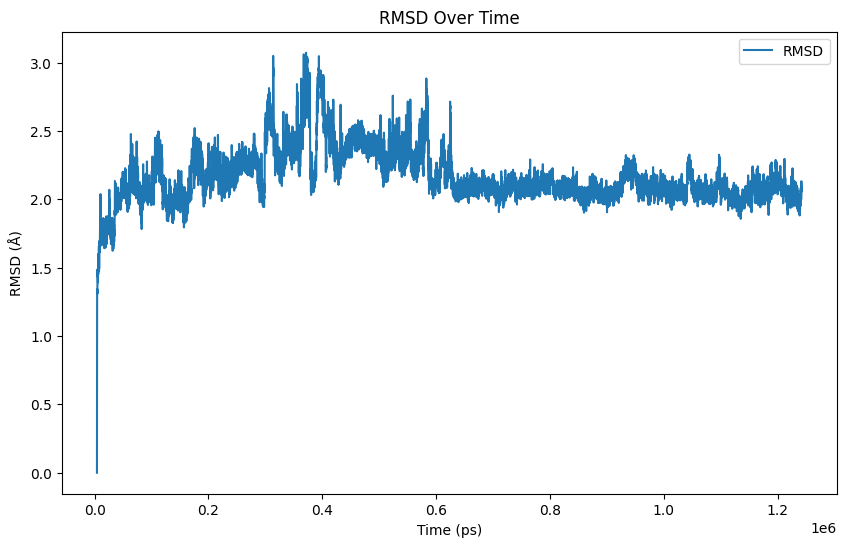

Exception ignored in: <function ReaderBase.__del__ at 0x2b322b6c63a0>
Traceback (most recent call last):
  File "/home/bathirjsr/.local/lib/python3.8/site-packages/MDAnalysis/coordinates/base.py", line 1512, in __del__
    self.close()
  File "/home/bathirjsr/.local/lib/python3.8/site-packages/MDAnalysis/coordinates/TRJ.py", line 701, in close
    if self.trjfile is not None:
AttributeError: 'NCDFReader' object has no attribute 'trjfile'


ValueError: x and y must have same first dimension, but have shapes (339,) and (5331,)

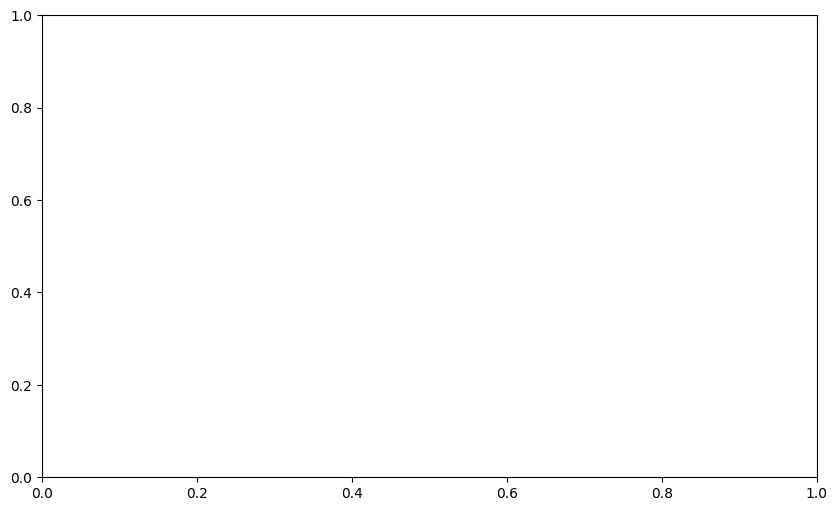

In [14]:
# Plot RMSD
plt.figure(figsize=(10, 6))
plt.plot(rmsd.times, rmsd.rmsd[:, 2], label='RMSD')
plt.xlabel('Time (ps)')
plt.ylabel('RMSD (Å)')
plt.title('RMSD Over Time')
plt.legend()
plt.savefig('rmsd.png')
plt.show()

# Plot RMSF
residues = [res.resid for res in protein.residues]
plt.figure(figsize=(10, 6))
plt.plot(residues, rmsf, label='RMSF')
plt.xlabel('Residue')
plt.ylabel('RMSF (Å)')
plt.title('RMSF per Residue')
plt.legend()
plt.savefig('rmsf.png')
plt.show()
